In [1]:
packages <- c("ggplot2", "dplyr", "tidyr", "arrow", "patchwork", "RColorBrewer")
for (pkg in packages) {
    suppressMessages(
        suppressWarnings(
            library(pkg, character.only = TRUE)
    )   )
}

dir.create("../figures", showWarnings = FALSE, recursive = TRUE)

In [2]:
# Get the current working directory and find Git root
find_git_root <- function() {
    cwd <- getwd()
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }
    current_path <- cwd
    while (dirname(current_path) != current_path) {
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }
    stop("No Git root directory found.")
}

root_dir <- find_git_root()
source(file.path(root_dir, "utils", "r_plot_themes.r"))

In [3]:
# Same profile-labeling helpers as 2.visualize_model_results.ipynb, kept
# self-contained here rather than sourced from that notebook, since
# notebooks can't import cells from one another.
label_profile_type <- function(profile_type) {
    pt <- tolower(profile_type)
    dplyr::case_when(
        grepl("nucleocentric", pt) & grepl("chammi|morphem", pt) ~ "Nucleocentric MorphEM",
        grepl("nucleocentric", pt) & grepl("sammed", pt) ~ "Nucleocentric SAMMed3D",
        grepl("sammed", pt) ~ "SAMMed3D",
        grepl("morphem|chammi", pt) ~ "MorphEM",
        grepl("zedprofiler", pt) ~ "ZedProfiler",
        grepl("^organoid", pt) ~ "Organoid",
        grepl("^sc", pt) ~ "Single-cell",
        TRUE ~ gsub("_", " ", tools::toTitleCase(pt))
    )
}

label_normalization_scope <- function(profile_type) {
    dplyr::case_when(
        grepl("norm_sc", profile_type, ignore.case = TRUE) ~ "Cross-patient normalized",
        TRUE ~ "Per-patient normalized"
    )
}

add_feature_type <- function(df) {
    df %>%
        mutate(
            Metadata_feature_type = label_profile_type(Metadata_profile_type),
            Metadata_normalization_scope = label_normalization_scope(Metadata_profile_type),
            Metadata_profile_label = paste0(
                Metadata_feature_type, "\n(", Metadata_normalization_scope, ")"
            )
        )
}

# SAMMed3D and MorphEM (and their nucleocentric variants) are the DL
# embedding-based feature sets - their individual dimensions aren't
# biologically interpretable, so panels A/B below drop them and keep
# only the handcrafted Organoid / Single-cell profiles.
is_dl_profile_label <- function(profile_label) {
    grepl("SAMMed3D|MorphEM", profile_label)
}

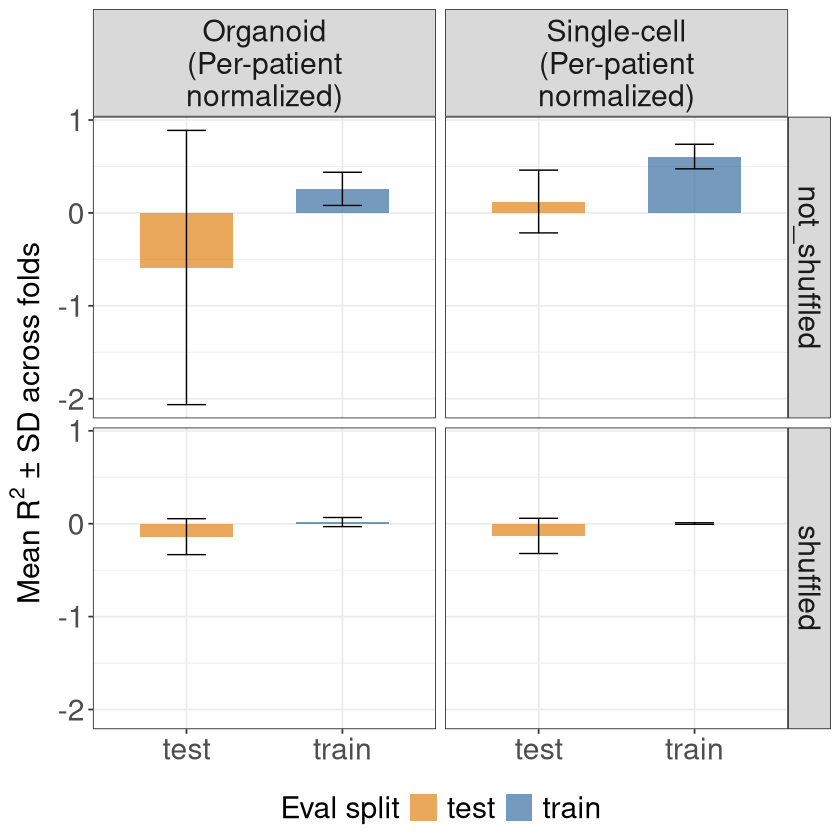

In [4]:
# ---------------------------------------------------------------------
# Panel A: 2.visualize_model_results.ipynb's page 1 (R2 by profile,
# lopo split) with the DL-embedding facets (SAMMed3D / MorphEM /
# Nucleocentric variants) dropped, leaving only the handcrafted
# Organoid and Single-cell profiles.
# ---------------------------------------------------------------------
eval_split_colors <- c(
    train = "#3B6FA0",
    test  = "#E08214"
)

fold_metrics_df <- arrow::read_parquet(file.path("../model_results/combined_fold_metrics.parquet")) %>%
    add_feature_type()

r2_lopo_df <- fold_metrics_df %>%
    filter(Metadata_split_method == "lopo", !is_dl_profile_label(Metadata_profile_label))

r2_summary_df <- r2_lopo_df %>%
    group_by(Metadata_eval_split, Metadata_shuffle_status, Metadata_profile_label) %>%
    summarise(mean_R2 = mean(R2), sd_R2 = sd(R2), .groups = "drop")

panel_a <- (
    ggplot(r2_summary_df, aes(x = Metadata_eval_split, y = mean_R2, fill = Metadata_eval_split))
    + geom_col(alpha = 0.7, width = 0.6)
    + geom_errorbar(aes(ymin = mean_R2 - sd_R2, ymax = mean_R2 + sd_R2), width = 0.25, linewidth = 0.4)
    + facet_grid(
        Metadata_shuffle_status ~ Metadata_profile_label,
        labeller = labeller(Metadata_profile_label = label_wrap_gen(width = 18))
    )
    + scale_fill_manual(values = eval_split_colors, name = "Eval split")
    + labs(x = NULL, y = expression("Mean " * R^2 * " ± SD across folds"))
    + theme_manuscript()
    # A right-side legend (ggplot's default) left the panel itself
    # narrow with blank space beyond it - a bottom legend, matching
    # panels B/C, lets the panel area stretch to the plot's full width.
    + theme(legend.position = "bottom")
)
panel_a

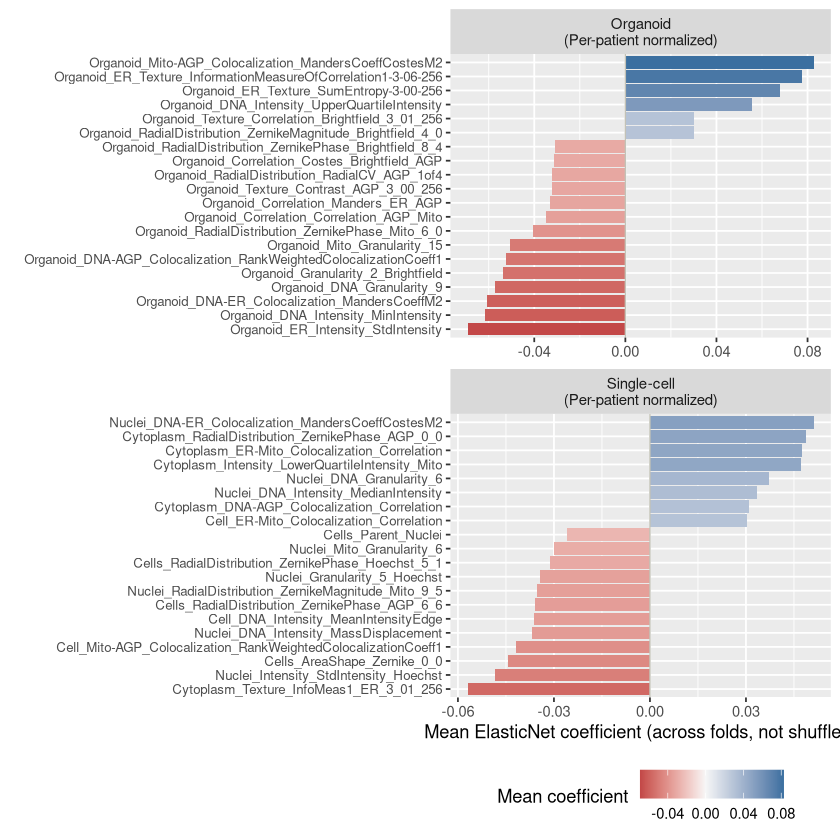

In [5]:
# ---------------------------------------------------------------------
# Panel B: 2.visualize_model_results.ipynb's page 9 (top-10 features by
# mean |coefficient|, already restricted to Organoid/Single-cell),
# further restricted to the random_split models only.
# ---------------------------------------------------------------------
reorder_within <- function(x, by, within, sep = "___") {
    new_x <- paste(x, within, sep = sep)
    stats::reorder(new_x, by)
}
scale_x_reordered <- function(..., sep = "___") {
    ggplot2::scale_x_discrete(labels = function(x) gsub(paste0(sep, ".+$"), "", x), ...)
}

feature_importances_df <- arrow::read_parquet(
    file.path("../model_results/combined_feature_importances.parquet")) %>%
    add_feature_type()

feature_importance_avg_df <- feature_importances_df %>%
    filter(Metadata_shuffle_status == "not_shuffled", !is_dl_profile_label(Metadata_profile_label)) %>%
    group_by(Metadata_profile_type, Metadata_split_method, Metadata_profile_label, feature) %>%
    summarise(mean_importance = mean(importance), .groups = "drop") %>%
    mutate(abs_importance = abs(mean_importance))

top_features_df <- feature_importance_avg_df %>%
    filter(Metadata_split_method == "random_split") %>%
    group_by(Metadata_profile_type, Metadata_split_method) %>%
    slice_max(order_by = abs_importance, n = 10, with_ties = FALSE) %>%
    ungroup()

panel_b <- (
    ggplot(
        top_features_df,
        aes(x = reorder_within(feature, mean_importance, Metadata_profile_label), y = mean_importance, fill = mean_importance)
    )
    + geom_col()
    + geom_hline(yintercept = 0, color = "#c3c2b7", linewidth = 0.4)
    + scale_x_reordered()
    + facet_wrap(~Metadata_profile_label, scales = "free", ncol = 1)
    + coord_flip()
    + scale_fill_gradient2(low = "#B2182B", mid = "#F7F7F7", high = "#3B6FA0", midpoint = 0, name = "Mean coefficient")
    + labs(x = NULL, y = "Mean ElasticNet coefficient (across folds, not shuffled)")
    + theme(axis.text.y = element_text(size = 8), strip.text = element_text(size = 9), legend.position = "bottom")
)
panel_b

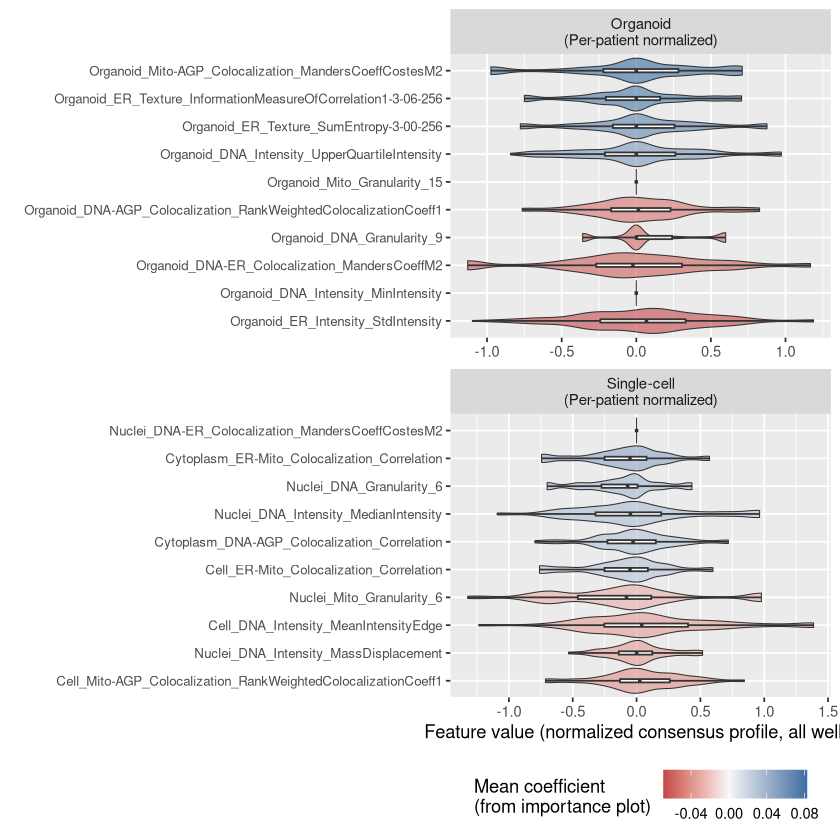

In [6]:
# ---------------------------------------------------------------------
# Panel C: 2.visualize_model_results.ipynb's page 11 (distribution of
# each model's top-10 features across all wells), restricted to the
# random_split models - it was already Organoid/Single-cell only, since
# the raw profiles it reads (organoid_profile_consensus,
# sc_profile_consensus) never included the DL embeddings to begin with.
# ---------------------------------------------------------------------
raw_profile_paths <- c(
    organoid_profile_consensus = file.path(root_dir, "3.viability_prediction_models/data/processed_profiles_3D/organoid_profile_consensus.parquet"),
    sc_profile_consensus       = file.path(root_dir, "3.viability_prediction_models/data/processed_profiles_3D/sc_profile_consensus.parquet")
)

top_feature_names <- unique(top_features_df$feature)

feature_values_list <- list()
for (pt in names(raw_profile_paths)) {
    raw_df <- arrow::read_parquet(raw_profile_paths[[pt]])
    keep_cols <- intersect(top_feature_names, colnames(raw_df))
    feature_values_list[[pt]] <- raw_df %>%
        select(all_of(keep_cols)) %>%
        mutate(Metadata_profile_type = pt) %>%
        pivot_longer(cols = all_of(keep_cols), names_to = "feature", values_to = "value")
}
feature_values_df <- bind_rows(feature_values_list)

feature_dist_df <- feature_values_df %>%
    inner_join(
        top_features_df %>% select(Metadata_profile_type, feature, mean_importance, Metadata_profile_label),
        by = c("Metadata_profile_type", "feature"),
        relationship = "many-to-many"
    ) %>%
    group_by(Metadata_profile_label, feature) %>%
    mutate(
        q1 = quantile(value, 0.25, na.rm = TRUE),
        q3 = quantile(value, 0.75, na.rm = TRUE),
        iqr = q3 - q1,
        fence_low = q1 - 1.5 * iqr,
        fence_high = q3 + 1.5 * iqr,
        value_clipped = pmin(pmax(value, fence_low), fence_high)
    ) %>%
    ungroup()

panel_c <- (
    ggplot(
        feature_dist_df,
        aes(x = reorder_within(feature, mean_importance, Metadata_profile_label), y = value_clipped, fill = mean_importance)
    )
    + geom_violin(alpha = 0.6, linewidth = 0.3, scale = "width")
    + geom_boxplot(width = 0.12, outlier.size = 0.5, alpha = 0.9, fill = "white")
    + scale_x_reordered()
    + facet_wrap(~Metadata_profile_label, scales = "free", ncol = 1)
    + coord_flip()
    + scale_fill_gradient2(low = "#B2182B", mid = "#F7F7F7", high = "#3B6FA0", midpoint = 0, name = "Mean coefficient\n(from importance plot)")
    + labs(x = NULL, y = "Feature value (normalized consensus profile, all wells)")
    + theme(axis.text.y = element_text(size = 8), strip.text = element_text(size = 9), legend.position = "bottom")
)
panel_c

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Montage — TBD' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Montage — TBD' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Montage — TBD' in 'mbcsToSbcs': dot substituted for <94>”


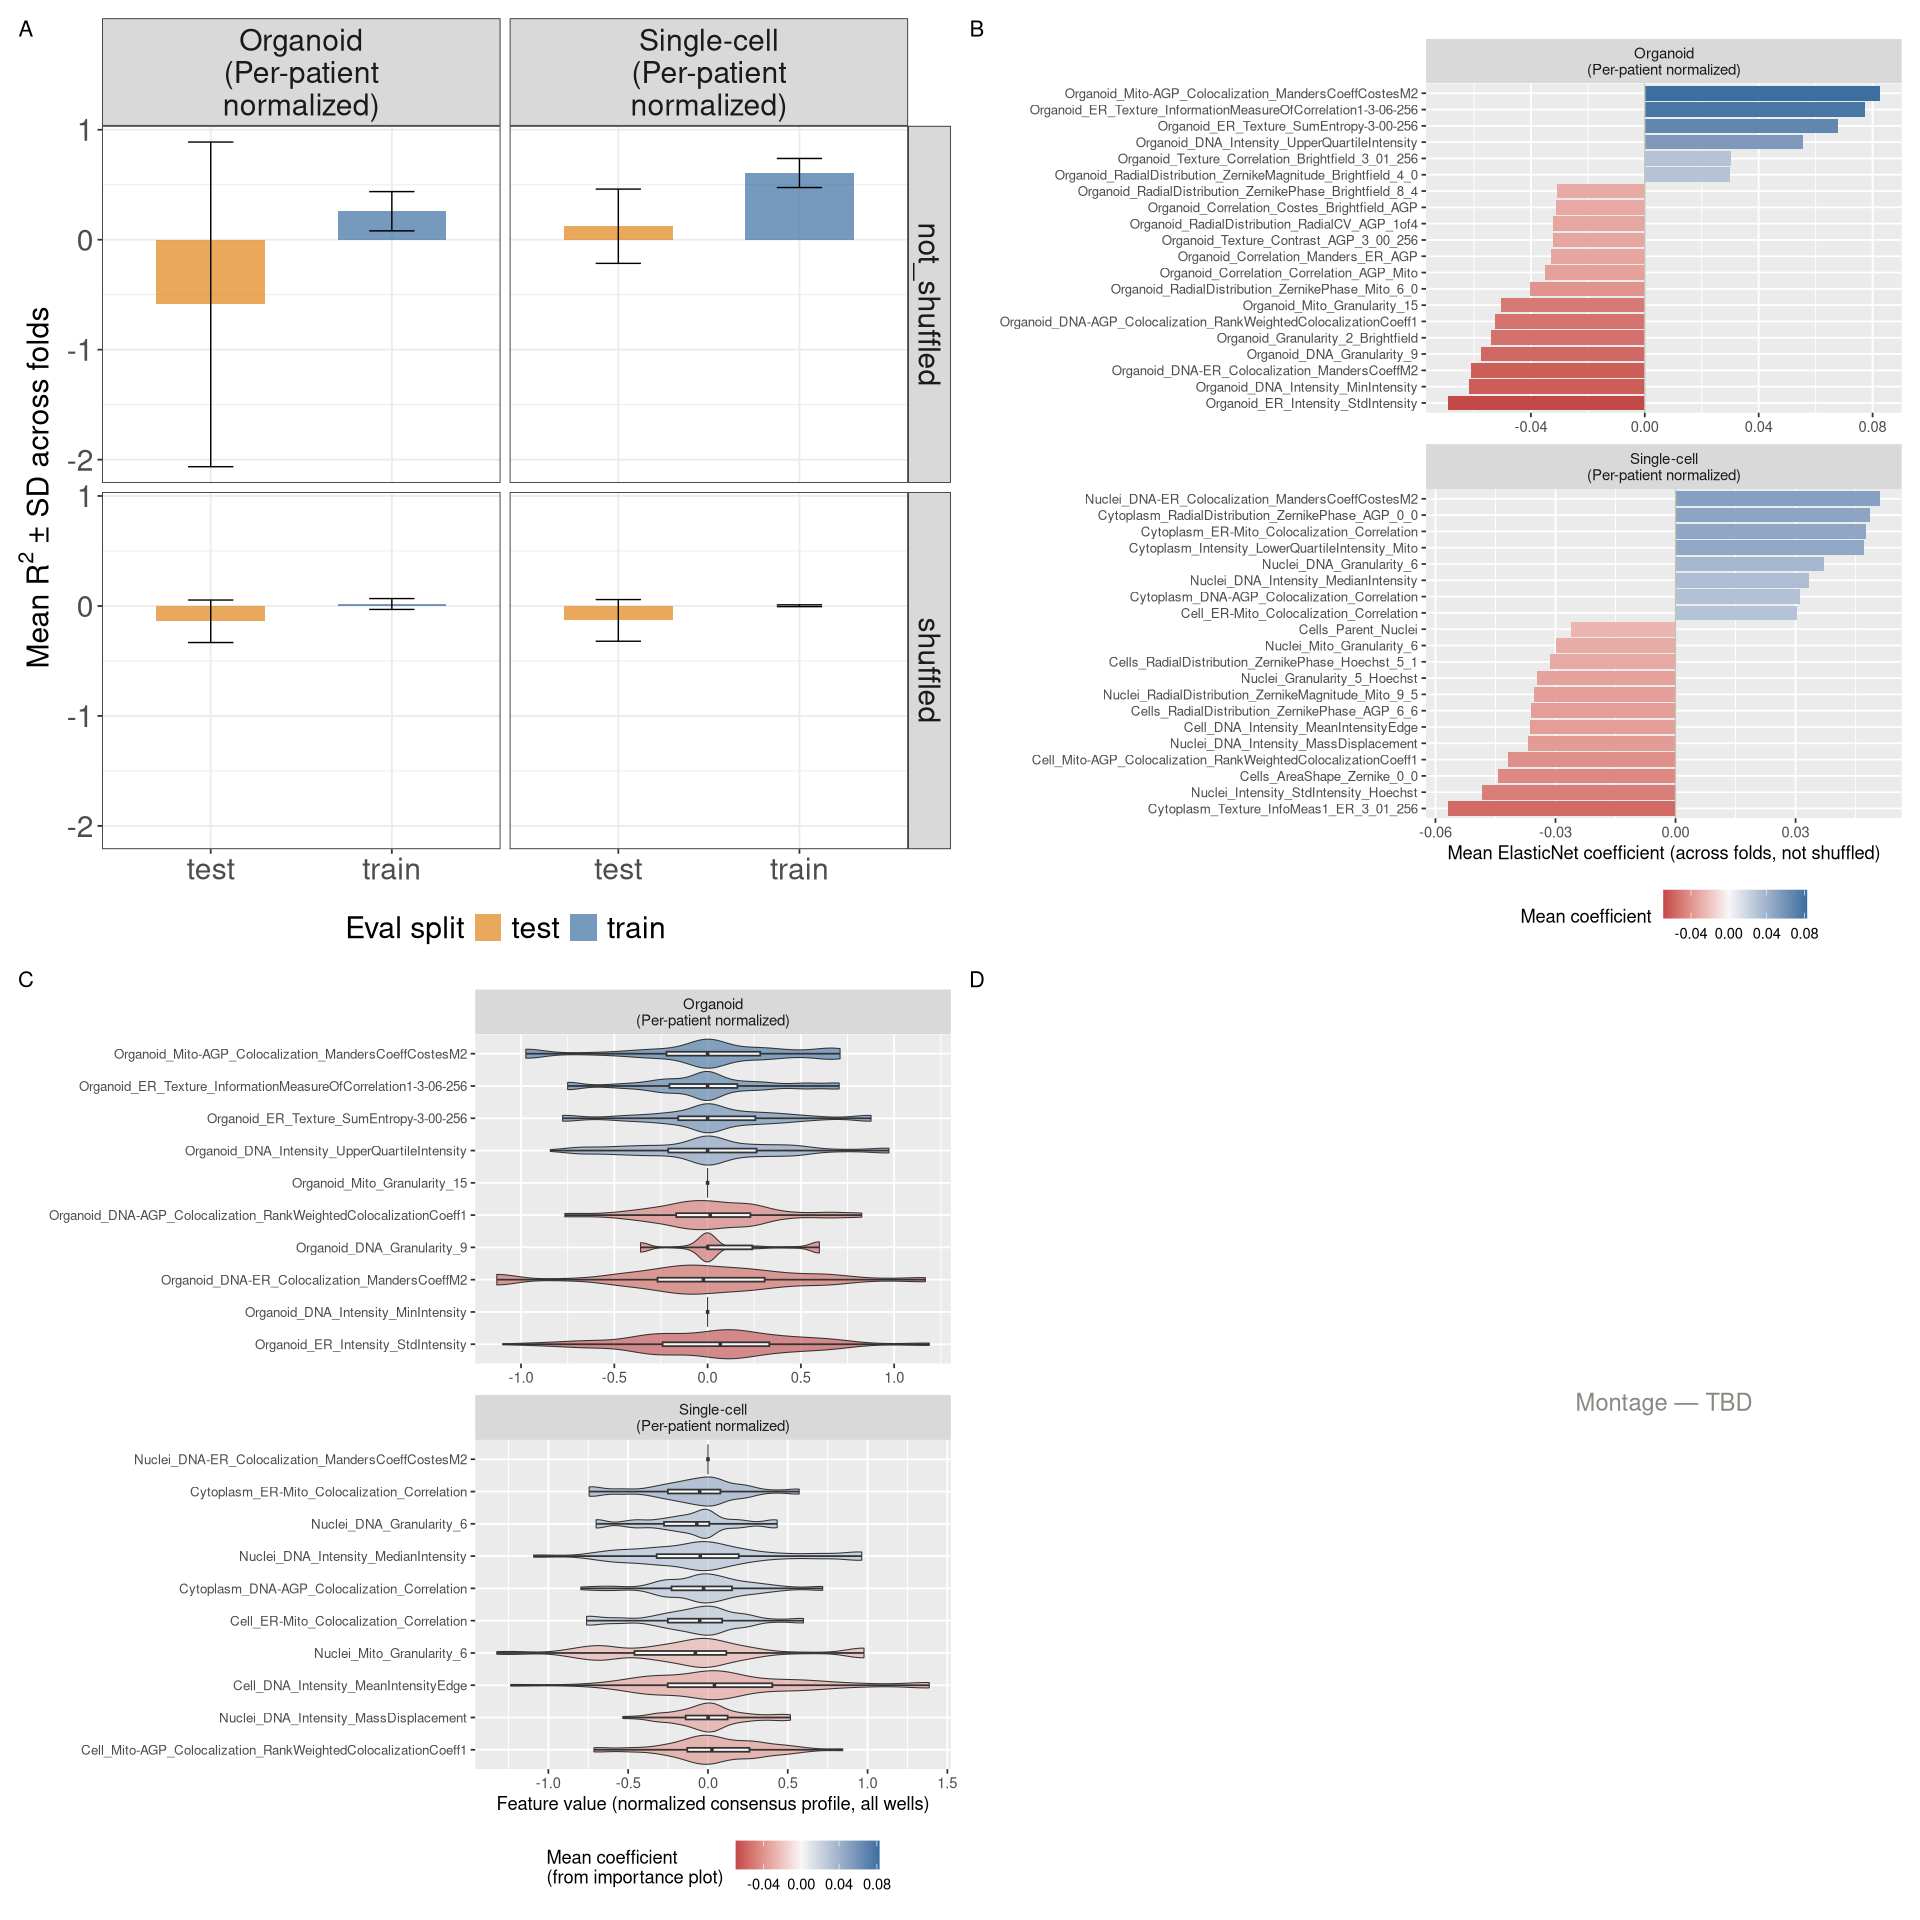

In [8]:
# Panel D is reserved for organoid/cell image montages (not yet built) -
# left as an empty placeholder so the 2x2 layout is already in place.
panel_d <- (
    ggplot()
    + xlim(0, 1) + ylim(0, 1)
    + annotate("text", x = 0.5, y = 0.5, label = "Montage — TBD", size = 5, color = "#898781")
    + theme_void()
)

options(repr.plot.width = 16, repr.plot.height = 16)
# A flat 2x2 grid (rather than nesting two row-composites and stacking
# them) so each panel gets an even, independent 50% x 50% cell - no
# cross-row alignment shrinking panel_a's cell to match panel_c's.
summary_figure <- (
    wrap_elements(full = panel_a) + panel_b + panel_c + panel_d
    + plot_layout(ncol = 2, nrow = 2)
    + plot_annotation(tag_levels = "A")
)

ggsave(
    filename = file.path("../figures", "multi_panel_summary_figure.png"),
    plot = summary_figure, width = 16, height = 16, dpi = 600
)
summary_figure